# Coffee Shop Revenue Analysis using Multiple Linear Regression

`Predict Revenue based on time, product category, and business drivers`

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Load Data

In [2]:
df = pd.read_excel("coffee_shop_dataset.xlsx", engine="openpyxl")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [3]:
df.dtypes

transaction_id               int64
transaction_date    datetime64[us]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location                 str
product_id                   int64
unit_price                 float64
product_category               str
product_type                   str
product_detail                 str
dtype: object

## Feature Engineering

In [4]:
from datetime import time

df['revenue'] = df['transaction_qty'] * df['unit_price']

# Extract time features
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')
df['hour'] = df['transaction_time'].dt.hour

def time_period(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    else:
        return 'night'

# Apply time bucket
df['time_period'] = df['hour'].apply(time_period)

# Day of week
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['day_of_week'] = df['transaction_date'].dt.day_name()
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,hour,time_period,day_of_week
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,7,morning,Sunday
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,morning,Sunday
2,3,2023-01-01,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,7,morning,Sunday
3,4,2023-01-01,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,7,morning,Sunday
4,5,2023-01-01,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,morning,Sunday


## Aggregate Data

In [5]:
grouped_df = df.groupby([
    'time_period',
    'product_category',
    'store_location',
    'day_of_week'
]).agg({
    'revenue': 'sum'
}).reset_index()
grouped_df.head()

,time_period,product_category,store_location,day_of_week,revenue
0,afternoon,Bakery,Astoria,Friday,1444.50
1,afternoon,Bakery,Astoria,Monday,1701.00
2,afternoon,Bakery,Astoria,Saturday,1509.25
3,afternoon,Bakery,Astoria,Sunday,1502.50
4,afternoon,Bakery,Astoria,Thursday,1700.25


## Features & Targets

In [6]:
features = [
    'time_period',
    'product_category',
    'store_location',
    'day_of_week'
]

target = 'revenue'

X = pd.get_dummies(grouped_df[features], drop_first=True)
y = grouped_df[target]

In [7]:
X.shape


(558, 18)

In [8]:
y.shape

(558,)

## Split Data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Prediction

In [10]:
reg = LinearRegression()
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = reg.predict(X_test)

## Evaluation

In [12]:
reg.coef_

array([ 6.58946835e+02, -1.02564868e+03, -1.03119167e+03,  2.88658398e+03,
       -6.85324704e+02, -1.67772868e+02, -1.16711732e+03, -1.17373174e+03,
       -1.40518608e+03,  1.76016756e+03,  7.24473801e+01, -2.92134818e+01,
        2.36854431e+01, -8.48230610e+01, -5.46226770e+01, -8.27738952e-01,
       -8.40590407e+01,  1.63222167e+01])

In [13]:
reg.intercept_

np.float64(1444.6339870849592)

In [14]:
r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(r2)
print("Adjusted R2:", adjusted_r2)

0.7810559825110095
Adjusted R2: 0.7386797210615275


In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': reg.coef_
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients.head(5))


                          Feature  Coefficient
3         product_category_Coffee  2886.583977
9            product_category_Tea  1760.167565
0             time_period_morning   658.946835
10  store_location_Hell's Kitchen    72.447380
12             day_of_week_Monday    23.685443


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X.shape[1])]
print(vif_data)
"""
Low VIF values indicate that the features have little linear correlation with each other 
and do not violate the multicollinearity assumption in linear regression.
"""

                                feature       VIF
0                   time_period_morning  0.012294
1                     time_period_night  0.012702
2              product_category_Branded  0.029957
3               product_category_Coffee  0.029047
4         product_category_Coffee beans  0.035793
5   product_category_Drinking Chocolate  0.031433
6             product_category_Flavours  0.028269
7            product_category_Loose Tea  0.031978
8   product_category_Packaged Chocolate  0.030496
9                  product_category_Tea  0.029688
10        store_location_Hell's Kitchen  0.012292
11       store_location_Lower Manhattan  0.012240
12                   day_of_week_Monday  0.024278
13                 day_of_week_Saturday  0.025563
14                   day_of_week_Sunday  0.026405
15                 day_of_week_Thursday  0.026745
16                  day_of_week_Tuesday  0.025191
17                day_of_week_Wednesday  0.025223


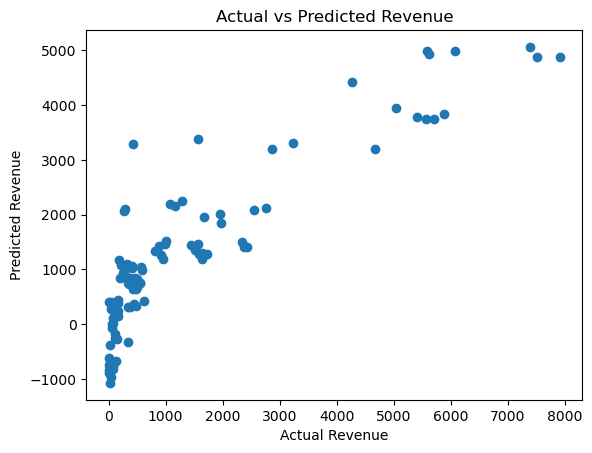

In [17]:
# ==============================
# STEP 13: VISUALIZATION
# ==============================
# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')
plt.show()


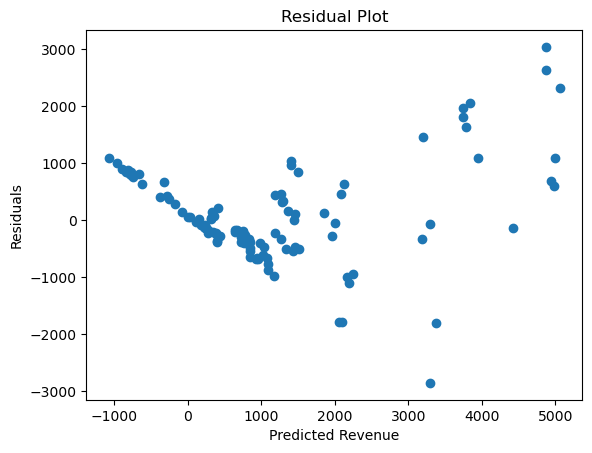

In [18]:
# Residual Plot
residuals = y_test - y_pred
plt.figure()
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted Revenue')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

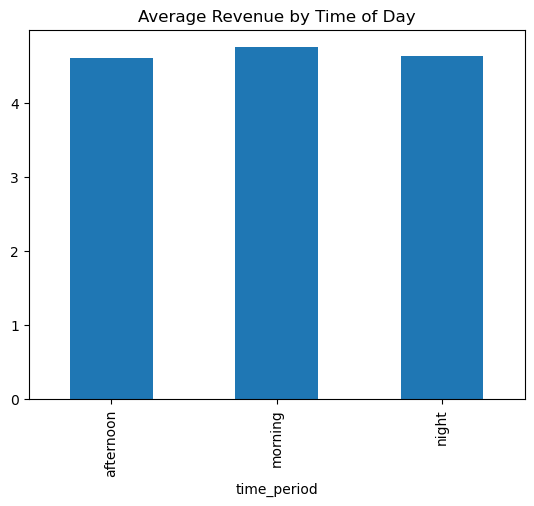

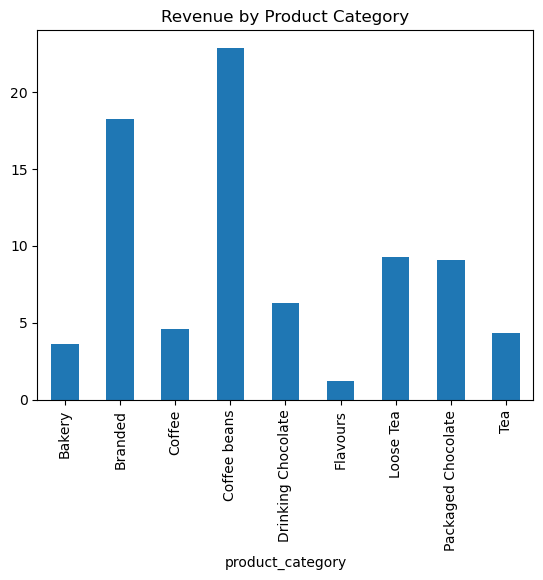

In [19]:
# ==============================
# STEP 14: OPTIONAL EDA VISUALS
# ==============================
# Revenue by time bucket
df.groupby('time_period')['revenue'].mean().plot(kind='bar')
plt.title('Average Revenue by Time of Day')
plt.show()

# Revenue by product category
df.groupby('product_category')['revenue'].mean().plot(kind='bar')
plt.title('Revenue by Product Category')
plt.show()